## AlphaGenome In-Silico Mutagenesis (ISM) Analysis
This notebook analyzes AlphaGenome variant scoring results from saturation mutagenesis experiments.
Optimized for analyzing hundreds of variants across a genomic region.

### Setup
1. Set the `INPUT_PATH` to your CSV file or directory containing AlphaGenome CSV files
2. Set the `OUTPUT_DIR` for saving results
3. Run all cells in order

## 1. Configuration

In [1]:
# ============================================
# CONFIGURATION - MODIFY THESE PATHS
# ============================================

# Input: Single CSV file or directory with multiple alphagenome_scores_*.csv files
INPUT_PATH = "../01_alphagenome_analysis/alphagenome_ISM_COL4A5_intron6/csv/" 
OUTPUT_DIR = "./plots_alphagenome_ISM/"

# Pathogenicity thresholds (can be customized)
THRESHOLD_HIGH = 0.999      # Top 0.1%
THRESHOLD_MODERATE = 0.99   # Top 1%
THRESHOLD_LOW = 0.95        # Top 5%

# Number of top variants to display in tables
TOP_N_VARIANTS = 20

## 2. Import Libraries

In [2]:
import glob
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Create output directory if needed
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Input path: {INPUT_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Input path: ../01_alphagenome_analysis/alphagenome_ISM_COL4A5_intron6/csv/
Output directory: ./plots_alphagenome_ISM/


## 3. Data Loading Function

In [3]:
def load_alphagenome_data(input_path: str) -> pd.DataFrame:
    """
    Load AlphaGenome data from either a single CSV file or a directory of CSV files.
    Optimized for large numbers of files.
    """
    input_path = Path(input_path)
    
    if input_path.is_file():
        print(f"Loading single file: {input_path.name}")
        combined_df = pd.read_csv(input_path)
    elif input_path.is_dir():
        file_pattern = str(input_path / 'alphagenome_scores_*.csv')
        files = glob.glob(file_pattern)
        
        if not files:
            file_pattern = str(input_path / '*.csv')
            files = glob.glob(file_pattern)
        
        if not files:
            raise FileNotFoundError(f"No CSV files found in {input_path}")
        
        print(f"Found {len(files)} CSV files")
        print(f"Loading files (this may take a moment for large datasets)...")
        
        # Efficient loading with progress indication
        dfs = []
        for i, f in enumerate(sorted(files)):
            if (i + 1) % 100 == 0:
                print(f"  Loaded {i + 1}/{len(files)} files...")
            dfs.append(pd.read_csv(f))
        
        combined_df = pd.concat(dfs, ignore_index=True)
        print(f"  Loaded all {len(files)} files.")
    else:
        raise FileNotFoundError(f"Input path not found: {input_path}")
    
    # Clean up
    if 'Unnamed: 0' in combined_df.columns:
        combined_df = combined_df.drop(columns=['Unnamed: 0'])
    
    # Data quality checks
    print(f"\n--- Data Summary ---")
    print(f"Total rows: {combined_df.shape[0]:,}")
    print(f"Unique variants: {combined_df['variant_id'].nunique():,}")
    
    return combined_df

## 4. Helper Functions

In [4]:
def classify_pathogenicity(quantile, threshold_high=0.999, threshold_moderate=0.99, threshold_low=0.95):
    """Classify variant pathogenicity based on quantile score."""
    if quantile >= threshold_high:
        return 'High Impact'
    elif quantile >= threshold_moderate:
        return 'Moderate Impact'
    elif quantile >= threshold_low:
        return 'Low Impact'
    else:
        return 'Likely Benign'

def parse_variant_id(variant_id):
    """Parse variant_id to extract chromosome, position, ref, and alt."""
    parts = variant_id.split(':')
    chrom = parts[0]
    position = int(parts[1])
    change = parts[2]
    ref = change.split('>')[0]
    alt = change.split('>')[1]
    return chrom, position, ref, alt, change

## 5. Create Variant Summary

In [5]:
def create_variant_summary(combined_df, threshold_high=0.999, threshold_moderate=0.99, threshold_low=0.95):
    """
    Create summary statistics for each variant.

    Uses the same logic and output schema as the cohort notebook
    (per-output-type splice metrics + classification based on
    SPLICE_SITE_USAGE quantile), but vectorised with groupby for
    efficiency on the large ISM dataset.
    """
    # Overall stats across all output types
    overall = combined_df.groupby('variant_id').agg(
        overall_max_raw=('raw_score', 'max'),
        overall_mean_raw=('raw_score', 'mean'),
        overall_max_quantile=('quantile_score', 'max'),
        overall_mean_quantile=('quantile_score', 'mean'),
        n_predictions=('output_type', 'count'),
    ).reset_index()

    # Per-output-type stats: SPLICE_JUNCTIONS
    sj = combined_df[combined_df['output_type'] == 'SPLICE_JUNCTIONS'].groupby('variant_id').agg(
        splice_junction_max_raw=('raw_score', 'max'),
        splice_junction_mean_raw=('raw_score', 'mean'),
        splice_junction_max_quantile=('quantile_score', 'max'),
        splice_junction_mean_quantile=('quantile_score', 'mean'),
    ).reset_index()

    # Per-output-type stats: SPLICE_SITE_USAGE
    ss = combined_df[combined_df['output_type'] == 'SPLICE_SITE_USAGE'].groupby('variant_id').agg(
        splice_site_max_raw=('raw_score', 'max'),
        splice_site_mean_raw=('raw_score', 'mean'),
        splice_site_max_quantile=('quantile_score', 'max'),
        splice_site_mean_quantile=('quantile_score', 'mean'),
    ).reset_index()

    summary = overall.merge(sj, on='variant_id', how='left').merge(ss, on='variant_id', how='left')

    # Parse variant IDs into chrom/position/ref/alt/change columns
    parsed = summary['variant_id'].apply(lambda x: pd.Series(parse_variant_id(x)))
    parsed.columns = ['chrom', 'position', 'ref', 'alt', 'change']
    summary = pd.concat([summary, parsed], axis=1)

    # Short variant label (e.g. "108570657:C>G"), to match cohort notebook
    summary['short_variant'] = summary['variant_id'].apply(
        lambda x: x.split(':')[1] + ':' + x.split(':')[2]
    )

    # Classification is based on the SPLICE_SITE_USAGE quantile score only
    # (matches the cohort notebook). If a variant has no SPLICE_SITE_USAGE
    # prediction it is labelled 'Not Evaluated'.
    summary['impact_class'] = summary['splice_site_max_quantile'].apply(
        lambda x: classify_pathogenicity(x, threshold_high, threshold_moderate, threshold_low)
        if pd.notna(x) else 'Not Evaluated'
    )

    summary = summary.sort_values('overall_max_quantile', ascending=False).reset_index(drop=True)

    return summary

## 6. Visualization Functions

### ISM Heatmap (Saturation Mutagenesis Landscape)

In [6]:
def plot_ism_heatmap(summary_df, output_dir=None, top_n=None):
    """
    Create a heatmap showing SPLICE_SITE_USAGE quantile scores for each
    position and nucleotide change. This is the classic saturation
    mutagenesis visualization, and uses the same metric that drives the
    pathogenicity classification in `create_variant_summary` (cohort logic).

    Parameters
    ----------
    summary_df : pd.DataFrame
        Variant summary dataframe.
    output_dir : str, optional
        Output directory for saving plots.
    top_n : int or None, optional
        Number of highest-scoring variants to include. Use None to include all variants.
    """
    # Keep only top N variants for a focused heatmap (or all if top_n is None)
    if top_n is not None:
        plot_df = summary_df.sort_values('splice_site_max_quantile', ascending=False).head(top_n).copy()
    else:
        plot_df = summary_df.copy()

    # Create pivot table: position x alt allele, coloured by splice-site usage
    pivot_data = plot_df.pivot_table(
        index='alt',
        columns='position',
        values='splice_site_max_quantile',
        aggfunc='max'
    )

    # Reorder rows to standard nucleotide order
    nucleotide_order = ['A', 'C', 'G', 'T']
    pivot_data = pivot_data.reindex([n for n in nucleotide_order if n in pivot_data.index])
    
    # Calculate figure width based on number of positions
    n_positions = len(pivot_data.columns)
    fig_width = max(16, n_positions * 0.12)
    
    fig, ax = plt.subplots(figsize=(fig_width, 4))
    
    # Custom colormap: green (benign) -> yellow -> orange -> red (pathogenic)
    colors = ['#4CAF50', '#FFC107', '#FF9800', '#D32F2F']
    cmap = LinearSegmentedColormap.from_list('pathogenicity', colors, N=256)
    
    # Create heatmap
    sns.heatmap(
        pivot_data,
        cmap=cmap,
        vmin=0.950,
        vmax=1.0,
        cbar_kws={'label': 'Splice-site usage quantile score', 'shrink': 0.8},
        ax=ax,
        xticklabels=True,
        yticklabels=True,
        linewidths=0.1,
        linecolor='white'
    )
    
    # Customize
    ax.set_xlabel('Genomic Position', fontsize=11)
    ax.set_ylabel('Alternative Allele', fontsize=11)
    ax.set_title('AlphaGenome ISM Heatmap - Saturation Mutagenesis Landscape\n(Higher score= more likely to disrupt splicing)', 
                 fontsize=12, fontweight='bold')
    
    # Rotate x-axis labels
    plt.xticks(rotation=90, fontsize=6)
    plt.yticks(fontsize=10)
    
    # Black border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'ism_heatmap.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_dir, 'ism_heatmap.svg'), bbox_inches='tight')
        print("Saved: ism_heatmap.png/svg")
    
    plt.show()

### Heatmap (top 20)

In [7]:
def plot_scores_heatmap(
    combined_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    output_dir: str = None,
    top_n: int = 20,
):
    """
    Create heatmap of scores by variant and output type.

    Parameters
    ----------
    combined_df : pd.DataFrame
        Combined AlphaGenome scores dataframe
    summary_df : pd.DataFrame
        Variant summary dataframe
    output_dir : str, optional
        Output directory for saving plots
    top_n : int, optional
        Number of highest-scoring variants to include in the heatmap
    """
    # Get max quantile score for each variant and output type
    heatmap_data = combined_df.groupby(['variant_id', 'output_type'])['quantile_score'].max().reset_index()
    heatmap_data['short_variant'] = heatmap_data['variant_id'].apply(
        lambda x: x.split(':')[1] + ':' + x.split(':')[2]
    )

    # Build short_variant in summary_df if not already present
    summary_plot = summary_df.copy()
    if 'short_variant' not in summary_plot.columns:
        summary_plot['short_variant'] = summary_plot['variant_id'].apply(
            lambda x: x.split(':')[1] + ':' + x.split(':')[2]
        )

    # Sort by overall impact and keep only top N variants
    top_variants = summary_plot.sort_values('overall_max_quantile', ascending=False).head(top_n)
    order = top_variants['short_variant'].tolist()

    # Pivot for heatmap and reindex to top variants order
    heatmap_pivot = heatmap_data.pivot(index='short_variant', columns='output_type', values='quantile_score')
    heatmap_pivot = heatmap_pivot.reindex(order)

    fig, ax = plt.subplots(figsize=(6, 6))

    sns.heatmap(
        heatmap_pivot,
        annot=True,
        fmt='.4f',
        cmap='RdYlGn_r',
        vmin=0.9,
        vmax=1.0,
        linewidths=0.5,
        cbar_kws={'label': 'Quantile Score'},
        ax=ax
    )

    ax.set_title(f'AlphaGenome scores by variant and prediction type (Top {len(order)})', fontsize=10)
    ax.set_xlabel('Prediction Type', fontsize=8)
    ax.set_ylabel('', fontsize=10)

    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, 'variant_scores_heatmap.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_dir, 'variant_scores_heatmap.svg'), bbox_inches='tight')
        print("Saved: variant_scores_heatmap.png/svg")

    plt.show()

## 7. Summary Functions

In [8]:
def print_summary_statistics(summary_df):
    """
    Print comprehensive summary statistics.
    """
    print("=" * 60)
    print("ISM ANALYSIS SUMMARY")
    print("=" * 60)
    
    # Basic stats
    print(f"\nTotal variants analyzed: {len(summary_df):,}")
    print(f"Genomic region: {summary_df['position'].min():,} - {summary_df['position'].max():,}")
    print(f"Region size: {summary_df['position'].max() - summary_df['position'].min() + 1:,} bp")
    print(f"Unique positions: {summary_df['position'].nunique():,}")
    
    # Impact classification
    print("\n--- Impact Classification ---")
    for impact in ['High Impact', 'Moderate Impact', 'Low Impact', 'Likely Benign']:
        count = len(summary_df[summary_df['impact_class'] == impact])
        pct = count / len(summary_df) * 100
        print(f"  {impact}: {count:,} ({pct:.1f}%)")
    
    # Score statistics
    print("\n--- Score Statistics ---")
    print(f"  Max quantile score: {summary_df['overall_max_quantile'].max():.6f}")
    print(f"  Min quantile score: {summary_df['overall_max_quantile'].min():.6f}")
    print(f"  Mean quantile score: {summary_df['overall_max_quantile'].mean():.6f}")
    print(f"  Median quantile score: {summary_df['overall_max_quantile'].median():.6f}")
    
    print("\n" + "=" * 60)


def get_top_variants(summary_df, n=20):
    """
    Get top N highest-scoring variants.
    """
    top = summary_df.head(n)[['variant_id', 'position', 'change', 'impact_class',
                              'overall_max_quantile', 'splice_junction_max_quantile', 
                              'splice_site_max_quantile']].copy()
    top.columns = ['Variant', 'Position', 'Change', 'Impact', 'Max Quantile', 
                   'Splice Junction', 'Splice Site']
    return top


def save_summary_table(summary_df, output_dir):
    """
    Save the full annotated variant summary to CSV.

    All columns produced by `create_variant_summary` are written out:
        - identifiers / coordinates: variant_id, short_variant, chrom, position, ref, alt, change
        - classification: impact_class
        - overall scores (across both output types): max/mean for raw and quantile
        - per-track scores for SPLICE_JUNCTIONS and SPLICE_SITE_USAGE: max/mean for raw and quantile
        - n_predictions
    """
    # Order columns logically: ids -> coords -> classification -> overall -> per-track -> count
    column_order = [
        'variant_id', 'short_variant', 'chrom', 'position', 'ref', 'alt', 'change',
        'impact_class',
        'overall_max_raw', 'overall_mean_raw',
        'overall_max_quantile', 'overall_mean_quantile',
        'splice_junction_max_raw', 'splice_junction_mean_raw',
        'splice_junction_max_quantile', 'splice_junction_mean_quantile',
        'splice_site_max_raw', 'splice_site_mean_raw',
        'splice_site_max_quantile', 'splice_site_mean_quantile',
        'n_predictions',
    ]

    # Keep only columns that actually exist (defensive against future schema changes)
    cols = [c for c in column_order if c in summary_df.columns]
    # Append any extra columns (so nothing gets silently dropped)
    extras = [c for c in summary_df.columns if c not in cols]
    output_df = summary_df[cols + extras].copy()

    # Human-readable header for the documented columns
    rename_map = {
        'variant_id': 'Variant ID',
        'short_variant': 'Short Variant',
        'chrom': 'Chromosome',
        'position': 'Position',
        'ref': 'Ref',
        'alt': 'Alt',
        'change': 'Change',
        'impact_class': 'Impact Classification',
        'overall_max_raw': 'Overall Max Raw',
        'overall_mean_raw': 'Overall Mean Raw',
        'overall_max_quantile': 'Overall Max Quantile',
        'overall_mean_quantile': 'Overall Mean Quantile',
        'splice_junction_max_raw': 'Splice Junction Max Raw',
        'splice_junction_mean_raw': 'Splice Junction Mean Raw',
        'splice_junction_max_quantile': 'Splice Junction Max Quantile',
        'splice_junction_mean_quantile': 'Splice Junction Mean Quantile',
        'splice_site_max_raw': 'Splice Site Max Raw',
        'splice_site_mean_raw': 'Splice Site Mean Raw',
        'splice_site_max_quantile': 'Splice Site Max Quantile',
        'splice_site_mean_quantile': 'Splice Site Mean Quantile',
        'n_predictions': 'N Predictions',
    }
    output_df = output_df.rename(columns=rename_map)

    # Round all numeric (float) columns to 6 decimals for readability
    float_cols = output_df.select_dtypes(include='float').columns
    output_df[float_cols] = output_df[float_cols].round(6)

    output_path = os.path.join(output_dir, 'ism_variant_summary.csv')
    output_df.to_csv(output_path, index=False)
    print(f"Saved: ism_variant_summary.csv ({len(output_df):,} variants, {len(output_df.columns)} columns)")

    return output_df

---
## 8. Run Analysis

### 8.1 Load Data

In [9]:
# Load AlphaGenome data
combined_df = load_alphagenome_data(INPUT_PATH)

# Display basic info
if 'gene_name' in combined_df.columns:
    print(f"Gene: {combined_df['gene_name'].unique()[0]}")
print(f"Output types: {combined_df['output_type'].unique().tolist()}")

Found 480 CSV files
Loading files (this may take a moment for large datasets)...
  Loaded 100/480 files...
  Loaded 200/480 files...
  Loaded 300/480 files...
  Loaded 400/480 files...
  Loaded all 480 files.

--- Data Summary ---
Total rows: 4,062
Unique variants: 480
Gene: COL4A5
Output types: ['SPLICE_JUNCTIONS', 'SPLICE_SITE_USAGE']


### 8.2 Create Summary

In [10]:
# Create variant summary
summary_df = create_variant_summary(
    combined_df,
    threshold_high=THRESHOLD_HIGH,
    threshold_moderate=THRESHOLD_MODERATE,
    threshold_low=THRESHOLD_LOW
)

# Print summary statistics
print_summary_statistics(summary_df)

ISM ANALYSIS SUMMARY

Total variants analyzed: 480
Genomic region: 108,570,633 - 108,570,792
Region size: 160 bp
Unique positions: 160

--- Impact Classification ---
  High Impact: 32 (6.7%)
  Moderate Impact: 67 (14.0%)
  Low Impact: 86 (17.9%)
  Likely Benign: 295 (61.5%)

--- Score Statistics ---
  Max quantile score: 0.999990
  Min quantile score: 0.928308
  Mean quantile score: 0.995553
  Median quantile score: 0.998364



### 8.3 Top Variants

In [11]:
# Display top variants
print(f"\nTop {TOP_N_VARIANTS} Highest-Scoring Variants:")
top_variants = get_top_variants(summary_df, TOP_N_VARIANTS)
display(top_variants)


Top 20 Highest-Scoring Variants:


,Variant,Position,Change,Impact,Max Quantile,Splice Junction,Splice Site
0,chrX:108570776:A>C,108570776,A>C,High Impact,0.999990,0.999990,0.999885
1,chrX:108570775:T>G,108570775,T>G,High Impact,0.999990,0.999990,0.999939
2,chrX:108570740:T>G,108570740,T>G,High Impact,0.999990,0.999990,0.999785
3,chrX:108570735:A>G,108570735,A>G,High Impact,0.999990,0.999990,0.999659
4,chrX:108570635:A>G,108570635,A>G,High Impact,0.999988,0.999988,0.999885
5,chrX:108570775:T>C,108570775,T>C,High Impact,0.999985,0.999985,0.999885
6,chrX:108570719:A>G,108570719,A>G,High Impact,0.999984,0.999984,0.999876
7,chrX:108570777:G>C,108570777,G>C,High Impact,0.999979,0.999979,0.999785
8,chrX:108570775:T>A,108570775,T>A,High Impact,0.999979,0.999979,0.999876
9,chrX:108570732:A>G,108570732,A>G,High Impact,0.999978,0.999978,0.999015


### 8.4 Generate Visualizations

Saved: ism_heatmap.png/svg


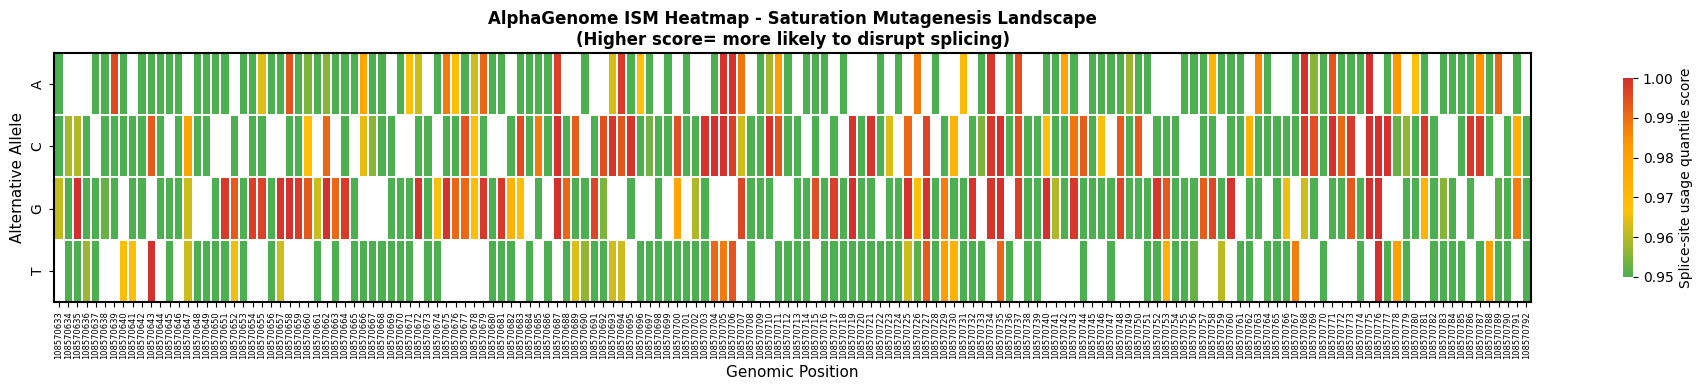

In [12]:
# Plot 1: ISM Heatmap (Saturation Mutagenesis Landscape)
plot_ism_heatmap(summary_df, OUTPUT_DIR)

Saved: variant_scores_heatmap.png/svg


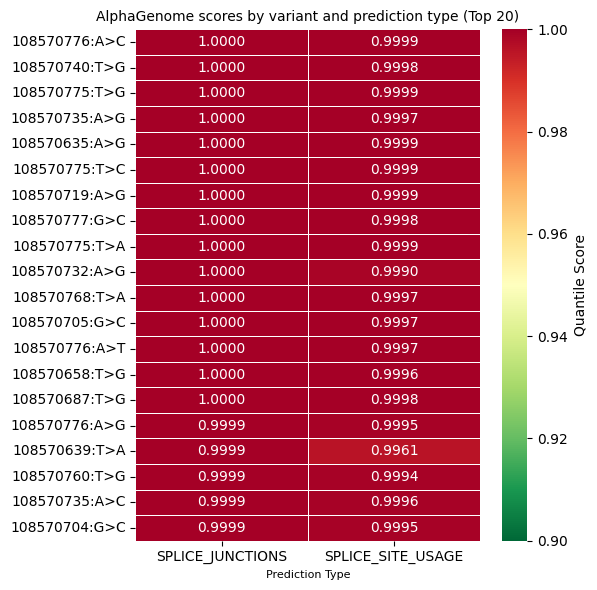

In [13]:
# Plot 2: Scores heatmap
plot_scores_heatmap(combined_df, summary_df, OUTPUT_DIR)

In [14]:
save_summary_table(summary_df,  output_dir="plots_alphagenome_ISM/")

Saved: ism_variant_summary.csv (480 variants, 21 columns)


,Variant ID,Short Variant,Chromosome,Position,Ref,Alt,Change,Impact Classification,Overall Max Raw,Overall Mean Raw,...,Overall Mean Quantile,Splice Junction Max Raw,Splice Junction Mean Raw,Splice Junction Max Quantile,Splice Junction Mean Quantile,Splice Site Max Raw,Splice Site Mean Raw,Splice Site Max Quantile,Splice Site Mean Quantile,N Predictions
0,chrX:108570776:A>C,108570776:A>C,chrX,108570776,A,C,A>C,High Impact,4.191406,1.905457,...,0.998780,4.191406,2.249969,0.999990,0.998514,0.598480,0.527405,0.999885,0.999844,10
1,chrX:108570775:T>G,108570775:T>G,chrX,108570775,T,G,T>G,High Impact,4.230469,2.553925,...,0.999957,4.230469,3.168945,0.999990,0.999970,0.777039,0.708862,0.999940,0.999918,8
2,chrX:108570740:T>G,108570740:T>G,chrX,108570740,T,G,T>G,High Impact,4.714844,2.165916,...,0.999854,4.714844,4.028320,0.999990,0.999987,0.356201,0.303513,0.999785,0.999722,4
3,chrX:108570735:A>G,108570735:A>G,chrX,108570735,A,G,A>G,High Impact,4.035156,1.835148,...,0.999757,4.035156,3.454102,0.999990,0.999981,0.251648,0.216194,0.999659,0.999533,4
4,chrX:108570635:A>G,108570635:A>G,chrX,108570635,A,G,A>G,High Impact,3.894531,1.822582,...,0.998713,3.894531,2.257589,0.999988,0.998336,0.593733,0.517562,0.999885,0.999844,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,chrX:108570714:C>T,108570714:C>T,chrX,108570714,C,T,C>T,Likely Benign,0.025162,0.014558,...,0.676853,0.025162,0.014994,0.895266,0.661368,0.011719,0.009766,0.947050,0.847186,24
476,chrX:108570708:A>T,108570708:A>T,chrX,108570708,A,T,A>T,Likely Benign,0.030167,0.015776,...,0.668975,0.030167,0.016603,0.942226,0.683056,0.007812,0.005859,0.686638,0.500000,26
477,chrX:108570718:C>G,108570718:C>G,chrX,108570718,C,G,C>G,Likely Benign,0.032990,0.016831,...,0.740906,0.032990,0.017958,0.942226,0.729788,0.007812,0.007812,0.879127,0.829846,18
478,chrX:108570692:A>T,108570692:A>T,chrX,108570692,A,T,A>T,Likely Benign,0.032318,0.017207,...,0.729763,0.032318,0.018251,0.939662,0.733500,0.007812,0.007812,0.715628,0.696127,20


---
## 9. Interpretation Guide

### Understanding the Results

**Quantile Scores:**
- Scores range from 0 to 1
- Higher scores indicate stronger predicted effects on splicing
- A score of 0.999 means the variant has a stronger effect than 99.9% of all possible variants

**Impact Classification:**
- **High Impact (≥0.999)**: Top 0.1% - Very likely to disrupt splicing
- **Moderate Impact (≥0.99)**: Top 1% - Likely to affect splicing
- **Low Impact (≥0.95)**: Top 5% - May have minor effects
- **Likely Benign (<0.95)**: Below top 5% - Unlikely to significantly affect splicing

**Key Visualizations:**
1. **ISM Heatmap**: Shows the complete saturation mutagenesis landscape. Hotspots (red regions) indicate positions where mutations are most likely to disrupt splicing.
2. **Score Distribution**: Shows how variants are distributed across impact classes.
3. **Genomic Track**: Highlights positions with the highest impact scores.
4. **Position Impact Summary**: Shows how many high/moderate/low impact variants exist at each position.